<a href="https://colab.research.google.com/github/sanganalasya-hash/Data-Science/blob/main/AP_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

In [1]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


# Part A

In [ ]:
econ = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_main.csv')

In [ ]:
econ

In [ ]:
sns.pairplot(econ)

In [ ]:
dag_econ = gv.Digraph(comment='bballh_dag') #bball hierarchy

dag_econ.node('H', 'Hemline')
dag_econ.node('Y','Year')
dag_econ.node('C','CCI')
dag_econ.node('U','Unemployment')
dag_econ.node('I','Income')

dag_econ.edges(['CH','UH', 'IH',  'UC', 'IC', 'UI'])

dag_econ

## Model 1

In [ ]:
#define the model
model_1 = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ, family="t")
#fit the model, generating posterior predictive samples directly
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_1 = model_1.predict(idata_1, kind='response')

In [ ]:
az.plot_ppc(idata_1, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 2

In [ ]:
#define the model
model_2 = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ, family="t")
#fit the model
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_2 = model_2.predict(idata_2, kind='response')

In [ ]:
az.plot_ppc(idata_2, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3

In [ ]:
#define the model
model_3 = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ, family="t")
#fit the model
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_3 = model_3.predict(idata_3, kind='response')

In [ ]:
az.plot_ppc(idata_3, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4

In [ ]:
model_4 = bmb.Model("Hemline ~ CCI + Unemployment + CCI:Unemployment + Year", data=econ, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [ ]:
pp_idata_4 = model_4.predict(idata_4, kind='response')

In [ ]:
az.plot_ppc(idata_4, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 5

In [ ]:
model_5 = bmb.Model("Hemline ~ CCI + Unemployment + CCI|Unemployment + Year", data=econ, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Compare A

In [ ]:
cmp_df = az.compare({
    'CCI + Year': idata_1,
    'Unemployment + Year': idata_2,
    'CCI + Unemployment + Year': idata_3,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4,
    'CCI + Unemployment + Year + CCI|Unemployment': idata_5,
})

display(cmp_df)

In [ ]:
az.plot_compare(cmp_df)

# Part B

In [3]:
econ_1 = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_with_income.csv')

In [ ]:
econ_1

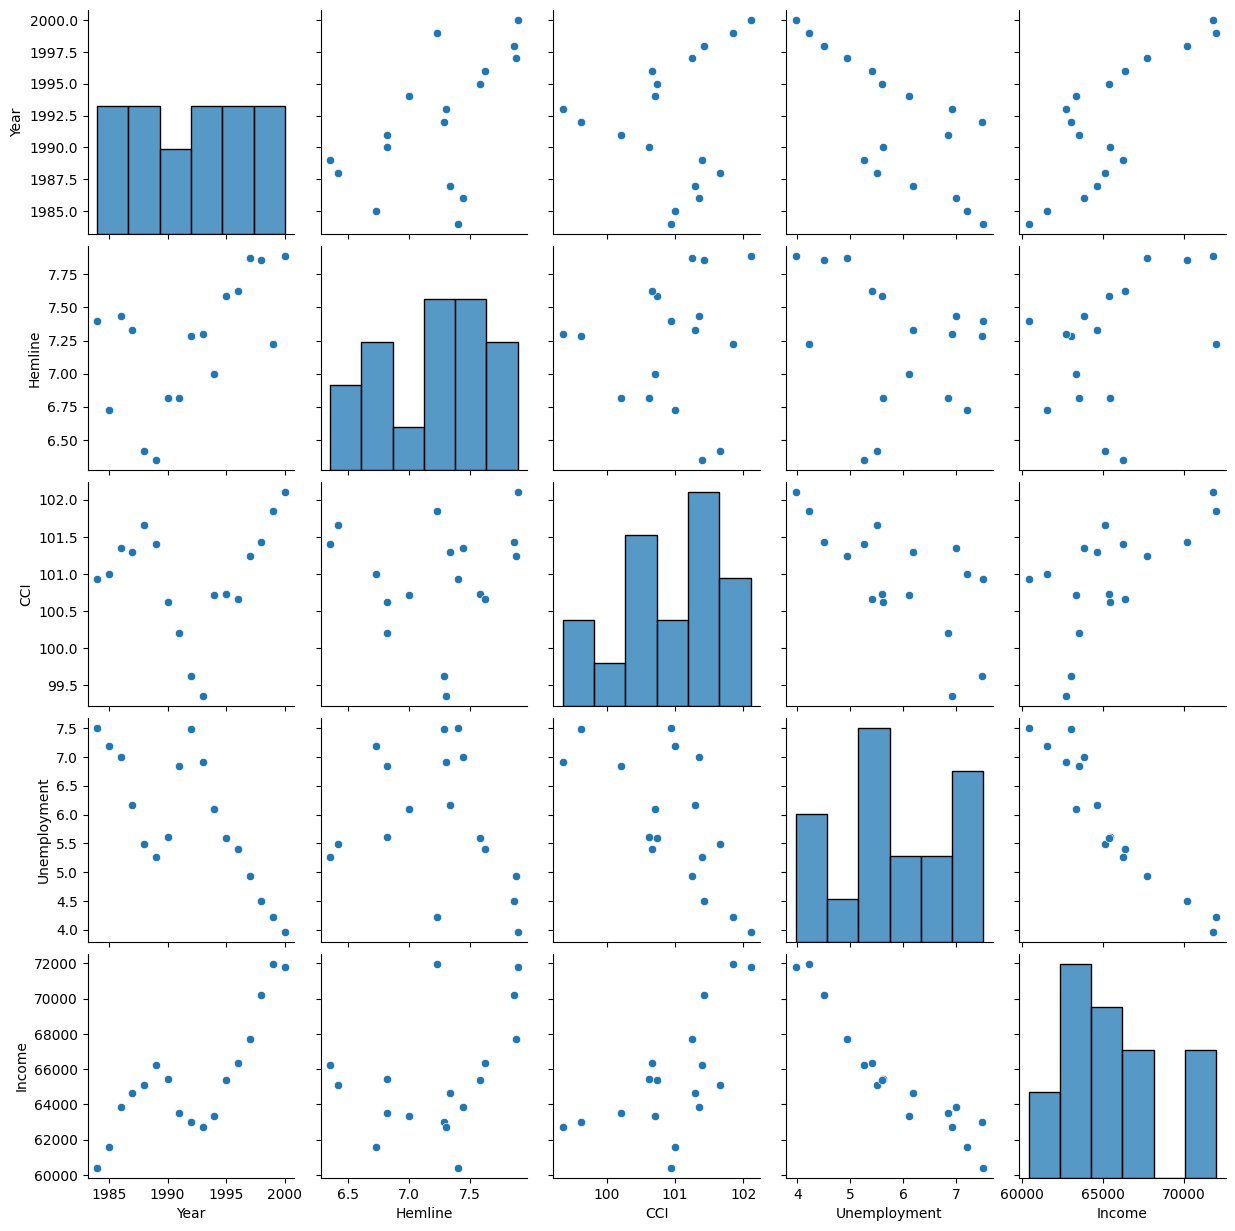

In [ ]:
sns.pairplot(econ_1)

## Model 1b

In [ ]:
#define the model
model_1b = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_1b = model_1b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_1b = model_1b.predict(idata_1b, kind='response')

In [ ]:
az.plot_ppc(idata_1b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 2b

In [ ]:
#define the model
model_2b = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ_1, family="t")
#fit the model
idata_2b = model_2b.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_2b = model_2b.predict(idata_2b, kind='response')

In [ ]:
az.plot_ppc(idata_2b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3b

In [ ]:
#define the model
model_3b = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ_1, family="t")
#fit the model
idata_3b = model_3b.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_3b = model_3b.predict(idata_3b, kind='response')

In [ ]:
az.plot_ppc(idata_3b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4b

In [ ]:
#define the model using the new interaction term
model_4b = bmb.Model("Hemline ~ CCI + Unemployment + CCI:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4b = model_4b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [ ]:
pp_idata_4b = model_4b.predict(idata_4b, kind='response')

In [ ]:
az.plot_ppc(idata_4b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 5

In [ ]:
#define the model
model_5 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_5 = model_5.predict(idata_5, kind='response')

In [ ]:
az.plot_ppc(idata_5, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 6

In [ ]:
#define the model
model_6 = bmb.Model("`Hemline` ~ `Income` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_6 = model_6.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_6 = model_6.predict(idata_6, kind='response')

In [ ]:
az.plot_ppc(idata_6, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 7

In [ ]:
#define the model
model_7 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `CCI` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_7 = model_7.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_7 = model_7.predict(idata_7, kind='response')

In [ ]:
az.plot_ppc(idata_7, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 8


In [ ]:
#define the model
model_8 = bmb.Model("Hemline ~ Income + Unemployment + Income:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_8 = model_8.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_8 = model_8.predict(idata_8, kind='response')

In [ ]:
az.plot_ppc(idata_8, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 9

In [ ]:
#define the model
model_9 = bmb.Model("Hemline ~ CCI + Unemployment:Income + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_9 = model_9.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 10


In [ ]:
#define the model
model_10 = bmb.Model("Hemline ~ Income:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_10 = model_10.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 11

In [ ]:
#define the model
model_11 = bmb.Model("Hemline ~ CCI:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_11 = model_11.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 12

In [ ]:
model_12 = bmb.Model("CCI ~ Unemployment", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_12 = model_12.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Compare B

In [30]:
cmp_df_1 = az.compare({
       'CCI': idata_1b,
    'Unemployment + Year': idata_2b,
    'CCI + Unemployment + Year': idata_3b,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4b,
    'Income + Unemployment + Year': idata_5,
    'Income + Year': idata_6,
    'CCI + Unemployment + Income + Year': idata_7,
    'Income + Unemployment + Year + Income:Unemployment': idata_8,
    'CCI + Unemployment:Income + Year': idata_9,
    'Income:Unemployment + Year': idata_10,
  'CCI:Unemployment + Year': idata_11,
  'CCI ~ Unemployment': idata_12
})

display(cmp_df_1)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Unemployment + Year,0,-10.776464,3.729556,0.000000,8.058650e-01,1.327242,0.000000,False,log
CCI + Unemployment + Year + CCI:Unemployment,1,-10.786957,3.680165,0.010493,1.941350e-01,1.247667,0.185778,False,log
CCI + Unemployment:Income + Year,2,-10.924116,3.846034,0.147651,0.000000e+00,1.415184,0.519276,False,log
Income:Unemployment + Year,3,-11.927263,3.520952,1.150798,0.000000e+00,1.692338,1.180459,False,log
CCI ~ Unemployment,4,-11.944386,3.572129,1.167921,0.000000e+00,1.720965,1.158975,False,log
CCI:Unemployment + Year,5,-11.953192,3.519484,1.176728,0.000000e+00,1.638463,1.089501,False,log
Unemployment + Year,6,-12.137814,3.686069,1.361350,0.000000e+00,1.739777,1.191524,False,log
CCI + Unemployment + Income + Year,7,-12.384987,4.997944,1.608523,4.748297e-15,1.473976,0.462888,False,log
Income + Year,8,-12.412499,3.557306,1.636035,0.000000e+00,1.983214,1.313368,False,log
CCI,9,-12.607295,3.548983,1.830831,0.000000e+00,2.102433,1.487700,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

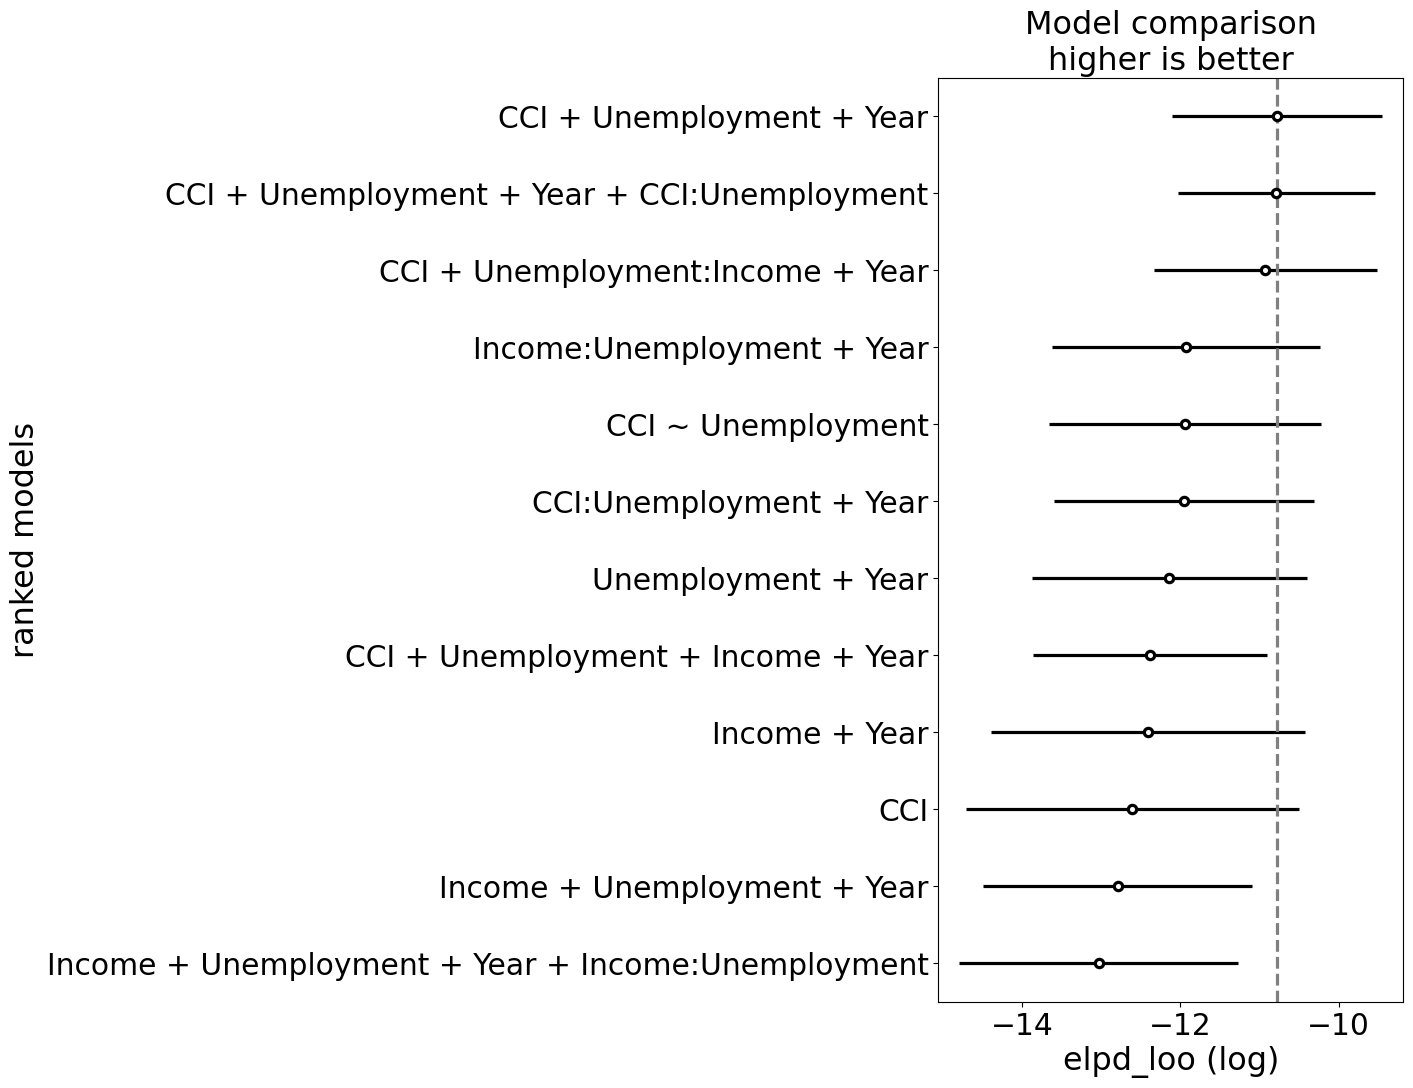

In [31]:
az.plot_compare(cmp_df_1)

# Part C

In [17]:
econ_1_lag = econ_1.copy()

econ_1_lag["CCI"] = econ_1_lag["CCI"].shift(3)
econ_1_lag["Unemployment"] = econ_1_lag["Unemployment"].shift(3)

econ_1_lag = econ_1_lag.dropna().copy()

In [18]:
econ_1_lag

,Year,Hemline,CCI,Unemployment,Income
3,1987,7.333333,100.936183,7.508333,64650
4,1988,6.416667,100.996592,7.191667,65130
5,1989,6.350000,101.349350,7.000000,66240
6,1990,6.818182,101.296958,6.175000,65440
7,1991,6.818182,101.666342,5.491667,63530
8,1992,7.285714,101.402525,5.258333,63010
9,1993,7.300000,100.627461,5.616667,62700
10,1994,7.000000,100.204170,6.850000,63370
11,1995,7.583333,99.621260,7.491667,65380
12,1996,7.625000,99.359034,6.908333,66340


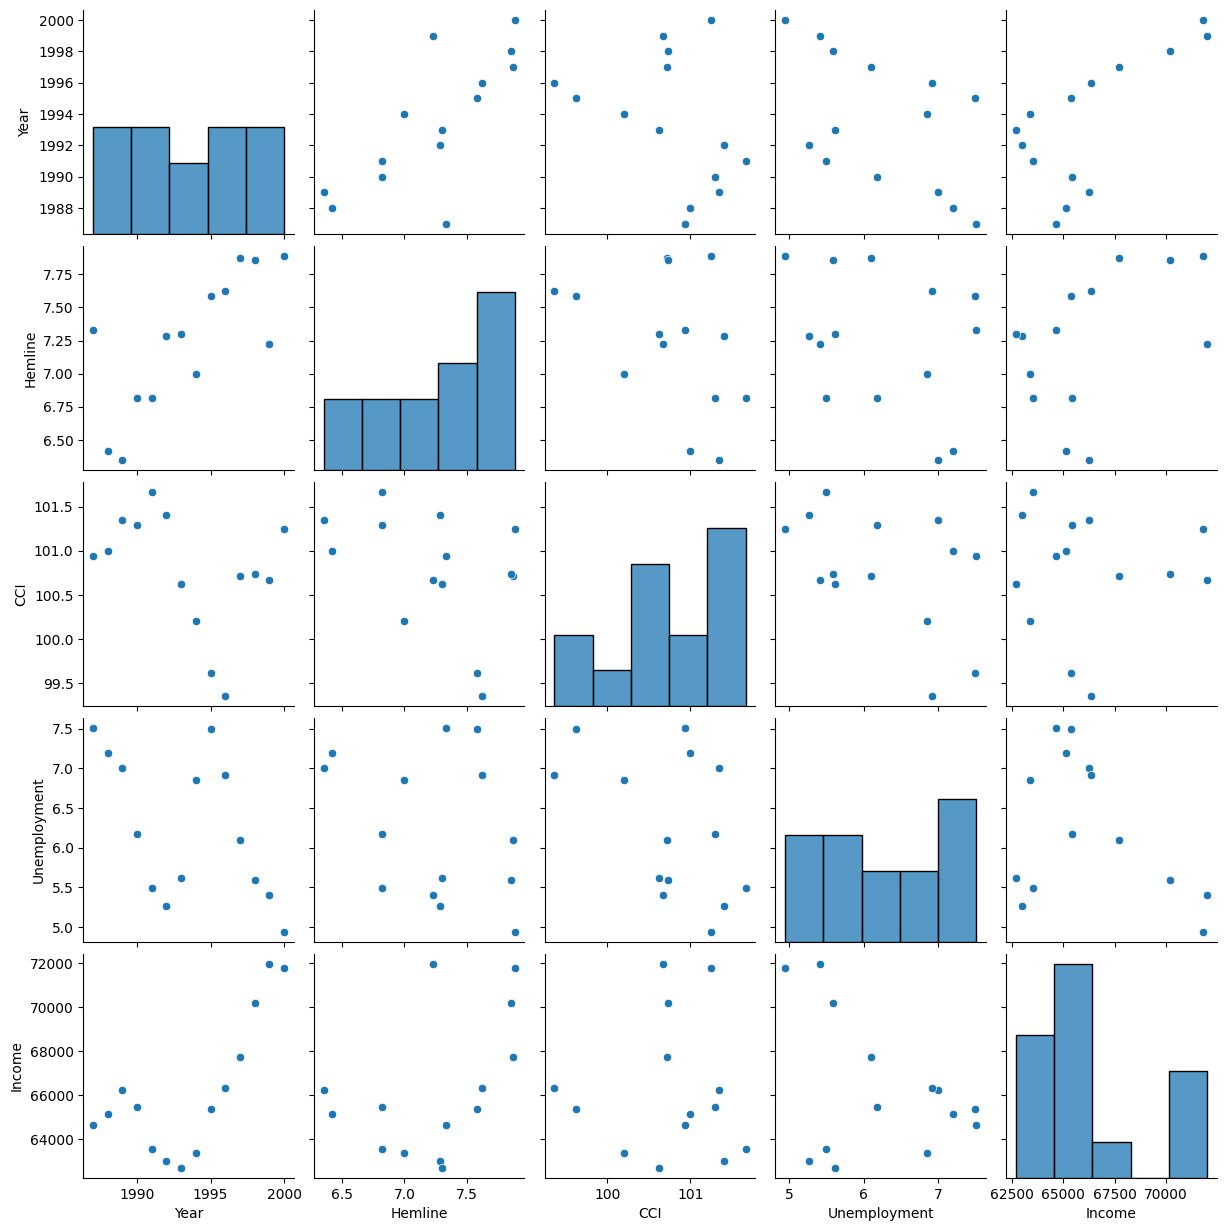

In [19]:
sns.pairplot(econ_1_lag)

## Model 1c

In [ ]:
#define the model
model_1c = bmb.Model("`Hemline` ~ CCI + Unemployment:Income + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly
idata_1c = model_1c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 2c

In [ ]:
#define the model
model_2c = bmb.Model("`Hemline` ~ CCI + Unemployment + Year", data=econ_1_lag, family="t")
#fit the model
idata_2c = model_2c.fit(idata_kwargs={'log_likelihood': True})

## Model 3c

In [ ]:
#define the model
model_3c = bmb.Model("`Hemline` ~ Unemployment + Year", data=econ_1_lag, family="t")
#fit the model
idata_3c = model_3c.fit(idata_kwargs={'log_likelihood': True})

## Model 4c

In [ ]:
model_4c = bmb.Model("Hemline ~ CCI:Unemployment + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4c = model_4c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Model 5c

In [ ]:
model_5c = bmb.Model("Hemline ~ CCI + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_5c = model_5c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Model 6c

In [ ]:
model_6c = bmb.Model("Hemline ~ Income + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_6c = model_6c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Compare C

In [38]:
cmp_df_c = az.compare({
    'CCI + Unemployment:Income + Year': idata_1c,
    'CCI + Unemployment + Year': idata_2c,
    'Unemployment + Year': idata_3c,
    'CCI:Unemployment + Year': idata_4c,
    'CCI + Year': idata_5c,
    'Income + Year': idata_6c
})

display(cmp_df_c)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Year,0,-8.463552,3.950624,0.000000,1.000000e+00,2.867533,0.000000,False,log
CCI:Unemployment + Year,1,-8.753724,3.998518,0.290172,5.273559e-16,2.811201,0.368013,False,log
Unemployment + Year,2,-8.832395,4.072846,0.368844,5.116687e-17,2.833887,0.347776,True,log
Income + Year,3,-9.307150,5.166796,0.843598,0.000000e+00,3.851346,1.246126,True,log
CCI + Unemployment:Income + Year,4,-9.691091,4.747437,1.227539,0.000000e+00,2.896776,0.408568,True,log
CCI + Unemployment + Year,5,-9.873700,4.767669,1.410148,3.441691e-15,2.749542,0.388716,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

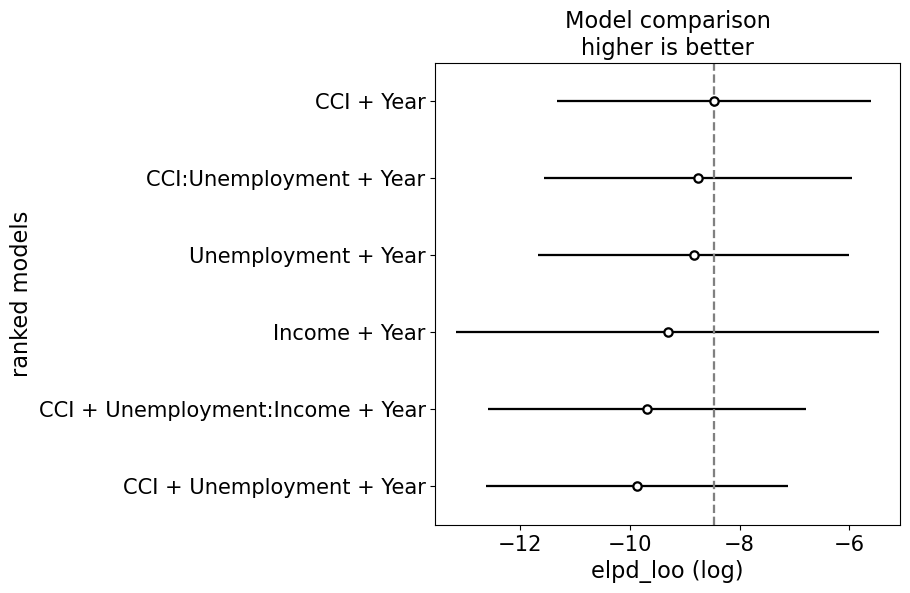

In [39]:
az.plot_compare(cmp_df_c)

## Compare Part C with Part A




In [40]:
print("Model comparison for Part B:")
display(cmp_df_1)

print("\nModel comparison for Part C:")
display(cmp_df_c)

Model comparison for Part B:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Unemployment + Year,0,-10.776464,3.729556,0.000000,8.058650e-01,1.327242,0.000000,False,log
CCI + Unemployment + Year + CCI:Unemployment,1,-10.786957,3.680165,0.010493,1.941350e-01,1.247667,0.185778,False,log
CCI + Unemployment:Income + Year,2,-10.924116,3.846034,0.147651,0.000000e+00,1.415184,0.519276,False,log
Income:Unemployment + Year,3,-11.927263,3.520952,1.150798,0.000000e+00,1.692338,1.180459,False,log
CCI ~ Unemployment,4,-11.944386,3.572129,1.167921,0.000000e+00,1.720965,1.158975,False,log
CCI:Unemployment + Year,5,-11.953192,3.519484,1.176728,0.000000e+00,1.638463,1.089501,False,log
Unemployment + Year,6,-12.137814,3.686069,1.361350,0.000000e+00,1.739777,1.191524,False,log
CCI + Unemployment + Income + Year,7,-12.384987,4.997944,1.608523,4.748297e-15,1.473976,0.462888,False,log
Income + Year,8,-12.412499,3.557306,1.636035,0.000000e+00,1.983214,1.313368,False,log
CCI,9,-12.607295,3.548983,1.830831,0.000000e+00,2.102433,1.487700,False,log



Model comparison for Part C:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Year,0,-8.463552,3.950624,0.000000,1.000000e+00,2.867533,0.000000,False,log
CCI:Unemployment + Year,1,-8.753724,3.998518,0.290172,5.273559e-16,2.811201,0.368013,False,log
Unemployment + Year,2,-8.832395,4.072846,0.368844,5.116687e-17,2.833887,0.347776,True,log
Income + Year,3,-9.307150,5.166796,0.843598,0.000000e+00,3.851346,1.246126,True,log
CCI + Unemployment:Income + Year,4,-9.691091,4.747437,1.227539,0.000000e+00,2.896776,0.408568,True,log
CCI + Unemployment + Year,5,-9.873700,4.767669,1.410148,3.441691e-15,2.749542,0.388716,False,log


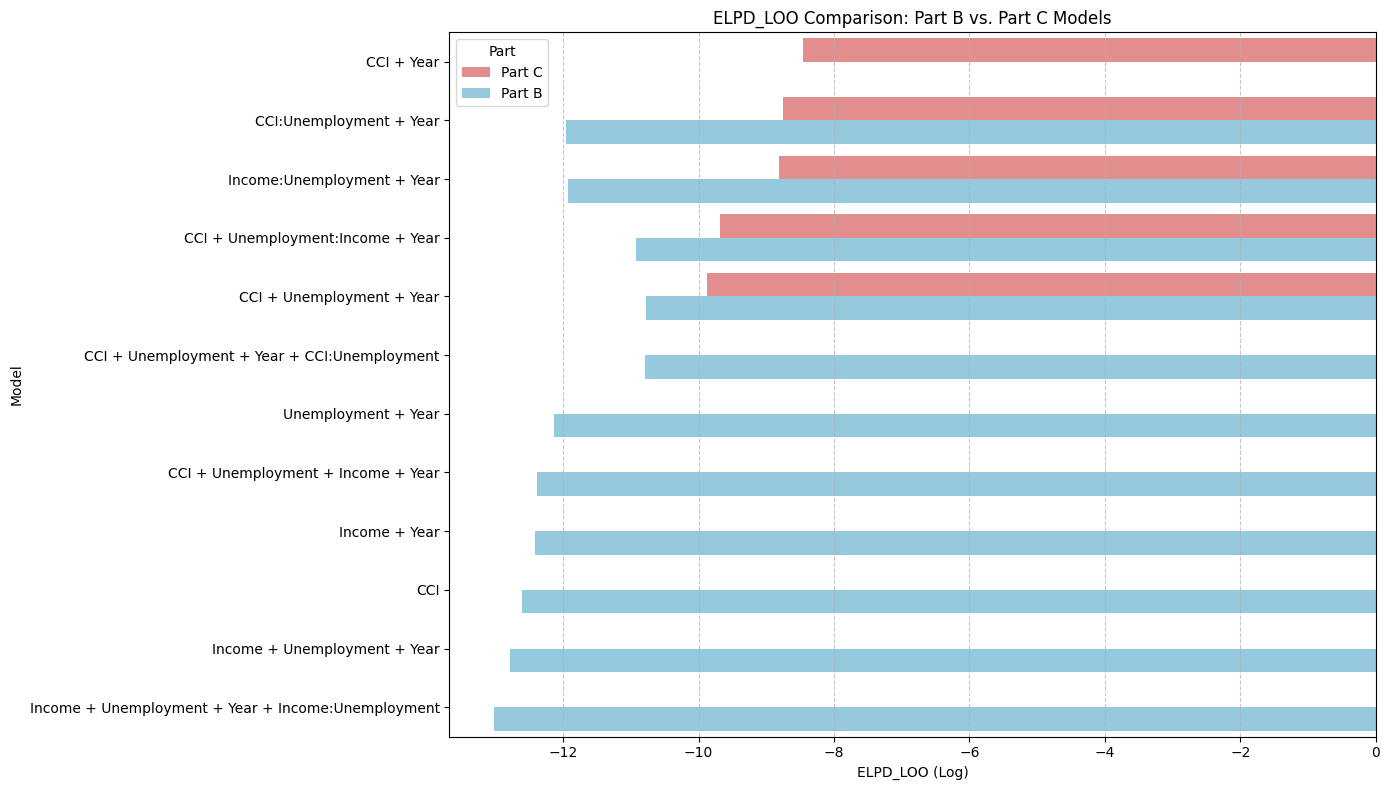

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract elpd_loo and model names from cmp_df_1 (Part B)
df_b_plot = cmp_df_1[['elpd_loo']].reset_index()
df_b_plot.rename(columns={'index': 'Model'}, inplace=True)
df_b_plot['Part'] = 'Part B'

# Extract elpd_loo and model names from cmp_df_c (Part C)
df_c_plot = cmp_df_c[['elpd_loo']].reset_index()
df_c_plot.rename(columns={'index': 'Model'}, inplace=True)
df_c_plot['Part'] = 'Part C'

# Concatenate the DataFrames
combined_elpd_loo = pd.concat([df_b_plot, df_c_plot])

# Create the plot
plt.figure(figsize=(14, 8))
sns.barplot(data=combined_elpd_loo.sort_values(by='elpd_loo', ascending=False),
            x='elpd_loo',
            y='Model',
            hue='Part',
            palette={'Part B': 'skyblue', 'Part C': 'lightcoral'},
            dodge=True)
plt.xlabel('ELPD_LOO (Log)')
plt.ylabel('Model')
plt.title('ELPD_LOO Comparison: Part B vs. Part C Models')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()